# Tumor growth-rate tracking across a therapy window

Longitudinal analysis of a single patient from the NCI Imaging Data Commons **`anti_pd_1_lung`**
collection (anti-PD-1 immunotherapy NSCLC cohort). Unlike NSCLC-Radiomics (single pre-treatment CT),
this collection has **multiple CT timepoints per patient** that bracket immunotherapy — so we can
measure how the tumor (GTV) changes over the treatment window.

**Patient:** `PD-1-Lung-00001` — two chest-CT timepoints, 57 days apart, each shipping an AI nodule
(tumor) segmentation, so GTV is available at every timepoint.

**Pipeline**
1. Configure patient
2. Query the CT timeline + nodule (tumor) segmentations per timepoint
3. Download **all** CT scans for the patient + the nodule SEGs
4. Read per-scan acquisition date/time + therapy-window metadata
5. Decode the nodule SEG → GTV (mL) at each timepoint
6. Growth metrics: interval, absolute/relative change, specific growth rate, volume doubling time
7. Visualize GTV over time + tumor overlay (baseline vs follow-up)

> Methodology note: dates in IDC/TCIA are anonymized per-patient but **intervals are preserved**, which
> is what growth-rate math needs. To keep model variability from masquerading as biological change, we
> use the *same* AI segmentation method at every timepoint.

## 0. Setup

Uses the shared `.idc-venv` (idc-index, SimpleITK, pydicom-seg, matplotlib). `pydicom-seg` needs
`pydicom<3`.

In [1]:
# !pip install idc-index SimpleITK pydicom-seg matplotlib "numpy<2" "pydicom<3"
import glob, math
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import SimpleITK as sitk
import pydicom, pydicom_seg
import matplotlib.pyplot as plt
from idc_index import IDCClient

client = IDCClient()
print("IDC data version:", client.get_idc_version())

IDC data version: v24


## 1. Configure patient

In [2]:
COLLECTION = "anti_pd_1_lung"
PATIENT    = "PD-1-Lung-00001"
DATA_DIR   = Path("data")            # downloads land here (relative to this notebook)
DATA_DIR.mkdir(exist_ok=True)

## 2. CT timeline and tumor (nodule) segmentations per timepoint

Each timepoint ships an *"AIMI lung and nodule AI segmentation"* whose `segmented_SeriesInstanceUID`
points at the CT series it was drawn on — that referenced CT defines the geometry we measure GTV in.

In [3]:
client.fetch_index("seg_index")

# Distinct CT timepoints (by StudyDate)
timeline = client.sql_query(f"""
    SELECT StudyDate, COUNT(DISTINCT SeriesInstanceUID) ct_series,
           ROUND(SUM(series_size_MB),1) size_MB
    FROM index
    WHERE collection_id='{COLLECTION}' AND PatientID='{PATIENT}' AND Modality='CT'
    GROUP BY StudyDate ORDER BY StudyDate
""")
print("CT timeline:")
print(timeline.to_string(index=False))

# The AI nodule segmentation at each timepoint + the CT series it references
nodule = client.sql_query(f"""
    SELECT i.StudyDate,
           i.SeriesInstanceUID    AS seg_uid,
           s.segmented_SeriesInstanceUID AS ref_ct_uid,
           s.SegmentedPropertyType_CodeMeanings AS seg_types
    FROM seg_index s JOIN index i USING (SeriesInstanceUID)
    WHERE i.collection_id='{COLLECTION}' AND i.PatientID='{PATIENT}'
      AND i.SeriesDescription = 'AIMI lung and nodule AI segmentation'
    ORDER BY i.StudyDate
""")
print("\nNodule (tumor) AI segmentations per timepoint:")
print(nodule.to_string(index=False))

2026-06-16 17:03:39,803 - Index seg_index already installed, loading from /Users/jinmo/Library/Application Support/idc_index_data/24.2.0/seg_index.parquet


CT timeline:
 StudyDate  ct_series  size_MB
2008-10-10          4    477.7
2008-12-06         10    974.6



Nodule (tumor) AI segmentations per timepoint:
 StudyDate                                                    seg_uid                                                       ref_ct_uid      seg_types
2008-10-10 1.2.276.0.7230010.3.1.3.17436516.2259859.1720642231.905041 1.3.6.1.4.1.14519.5.2.1.3098.5025.171063101400181377164698678716 [Lung, Nodule]
2008-12-06 1.2.276.0.7230010.3.1.3.17436516.2182223.1720640728.289751 1.3.6.1.4.1.14519.5.2.1.3098.5025.116203169560328194868664329413 [Lung, Nodule]


## 3. Download all CT scans for this patient + the nodule segmentations

Downloads are organized by StudyInstanceUID, so each timepoint (study) is a self-contained folder.

In [4]:
# All CT series for the patient
all_ct = client.sql_query(f"""
    SELECT SeriesInstanceUID FROM index
    WHERE collection_id='{COLLECTION}' AND PatientID='{PATIENT}' AND Modality='CT'
""")
ct_uids  = list(all_ct["SeriesInstanceUID"].values)
seg_uids = list(nodule["seg_uid"].values)

client.download_from_selection(
    downloadDir=str(DATA_DIR),
    seriesInstanceUID=ct_uids + seg_uids,
    dirTemplate="%StudyInstanceUID/%Modality_%SeriesInstanceUID",
)
n_dcm = len(glob.glob(str(DATA_DIR / "**/*.dcm"), recursive=True))
print(f"Downloaded {len(ct_uids)} CT series + {len(seg_uids)} SEG series  ({n_dcm} DICOM files)")

2026-06-16 17:03:41,974 - Disk size needed: 1.46 GB


2026-06-16 17:03:41,975 - Disk size available: 110.73 GB


2026-06-16 17:03:42,009 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested


2026-06-16 17:03:42,058 - Initial size of the directory: 3.51 MB


2026-06-16 17:03:42,060 - Approximate size of the files that need to be downloaded: 1.46 GB



2026-06-16 17:04:26,421 - Successfully downloaded files to /Users/jinmo/Documents/GitHub/Series1/ImageAnalysis_pubData/therapyNgrowthtracking/data


Downloaded 14 CT series + 2 SEG series  (2739 DICOM files)


## 4. Per-scan acquisition metadata + therapy window

Read the temporal DICOM tags from each referenced CT. The **therapy window** here is defined by the
imaging timeline: the `anti_pd_1_lung` cohort is, by construction, on anti-PD-1 immunotherapy, and the
scans are baseline / on-treatment assessments. (IDC does not expose explicit drug start/stop dates for
this collection, so the scan interval is the available proxy for the treatment window.)

In [5]:
def find_series_dir(uid):
    hits = glob.glob(str(DATA_DIR / "**" / f"CT_{uid}"), recursive=True)
    return hits[0] if hits else None

def read_ct(uid):
    folder = find_series_dir(uid)
    r = sitk.ImageSeriesReader()
    r.SetFileNames(r.GetGDCMSeriesFileNames(folder))
    return r.Execute(), folder

meta_rows = []
for _, row in nodule.iterrows():
    _, folder = read_ct(row["ref_ct_uid"])
    hdr = pydicom.dcmread(sorted(glob.glob(folder + "/*.dcm"))[0], stop_before_pixels=True)
    meta_rows.append({
        "StudyDate":       hdr.get("StudyDate", ""),
        "AcquisitionDate": hdr.get("AcquisitionDate", ""),
        "AcquisitionTime": hdr.get("AcquisitionTime", ""),
        "ref_ct_uid":      row["ref_ct_uid"],
        "seg_uid":         row["seg_uid"],
    })
meta = pd.DataFrame(meta_rows).sort_values("StudyDate").reset_index(drop=True)
t0 = datetime.strptime(meta.loc[0, "StudyDate"], "%Y%m%d")
meta["days_from_baseline"] = meta["StudyDate"].apply(
    lambda d: (datetime.strptime(d, "%Y%m%d") - t0).days)
print(meta.to_string(index=False))
print(f"\nTherapy/observation window: {meta['days_from_baseline'].max()} days "
      f"({meta.loc[0,'StudyDate']} -> {meta.iloc[-1]['StudyDate']}, anonymized dates)")

StudyDate AcquisitionDate AcquisitionTime                                                       ref_ct_uid                                                    seg_uid  days_from_baseline
 20081010        20081010   154332.693421 1.3.6.1.4.1.14519.5.2.1.3098.5025.171063101400181377164698678716 1.2.276.0.7230010.3.1.3.17436516.2259859.1720642231.905041                   0
 20081206        20081206   185640.724020 1.3.6.1.4.1.14519.5.2.1.3098.5025.116203169560328194868664329413 1.2.276.0.7230010.3.1.3.17436516.2182223.1720640728.289751                  57

Therapy/observation window: 57 days (20081010 -> 20081206, anonymized dates)


## 5. Measure GTV (tumor volume) at each timepoint

Decode the nodule SEG, resample it onto its referenced CT grid, and integrate voxel volume → mL.

In [6]:
def gtv_ml(seg_uid, ct_img):
    f = glob.glob(str(DATA_DIR / "**" / f"SEG_{seg_uid}" / "*.dcm"), recursive=True)[0]
    dcm = pydicom.dcmread(f)
    res = pydicom_seg.SegmentReader().read(dcm)
    sx, sy, sz = ct_img.GetSpacing()
    vol = 0.0
    masks = []
    for n in res.available_segments:
        label = dcm.SegmentSequence[n - 1].get("SegmentLabel", "")
        if "odule" in label or "umor" in label:           # tumor/nodule segment only
            img = res.segment_image(n)
            r = sitk.Resample(img, ct_img, sitk.Transform(),
                              sitk.sitkNearestNeighbor, 0, img.GetPixelID())
            arr = sitk.GetArrayFromImage(r).astype(bool)
            vol += arr.sum() * sx * sy * sz / 1000
            masks.append(arr)
    mask = np.any(masks, axis=0) if masks else None
    return vol, mask

ct_images, gtv_masks = {}, {}
gtvs = []
for _, row in meta.iterrows():
    cimg, _ = read_ct(row["ref_ct_uid"])
    v, m = gtv_ml(row["seg_uid"], cimg)
    ct_images[row["StudyDate"]] = cimg
    gtv_masks[row["StudyDate"]] = m
    gtvs.append(v)
meta["GTV_mL"] = np.round(gtvs, 3)
print(meta[["StudyDate", "days_from_baseline", "GTV_mL"]].to_string(index=False))

StudyDate  days_from_baseline  GTV_mL
 20081010                   0   1.859
 20081206                  57   0.698


## 6. Growth metrics

For consecutive timepoints (t0 → t1) with volumes V0, V1 over Δt days:

- **Absolute / relative change:** `V1 − V0`, `(V1 − V0)/V0`
- **Specific growth rate (SGR):** `ln(V1/V0) / Δt`  (per day)
- **Volume doubling time (VDT):** `Δt · ln(2) / ln(V1/V0)` — positive = growing, **negative = shrinking
  (treatment response)**

In [7]:
rows = []
for i in range(1, len(meta)):
    v0, v1 = meta.loc[i-1, "GTV_mL"], meta.loc[i, "GTV_mL"]
    dt = meta.loc[i, "days_from_baseline"] - meta.loc[i-1, "days_from_baseline"]
    sgr = math.log(v1/v0)/dt
    vdt = dt*math.log(2)/math.log(v1/v0)
    rows.append({
        "interval":     f"{meta.loc[i-1,'StudyDate']} -> {meta.loc[i,'StudyDate']}",
        "days":         dt,
        "V0_mL":        v0, "V1_mL": v1,
        "abs_change_mL": round(v1-v0, 3),
        "rel_change_%":  round((v1-v0)/v0*100, 1),
        "SGR_%per_day":  round(sgr*100, 3),
        "VDT_days":      round(vdt, 1),
    })
growth = pd.DataFrame(rows)
print(growth.to_string(index=False))

g = growth.iloc[0]
trend = "shrinking (treatment response)" if g["rel_change_%"] < 0 else "growing"
pr_vol = (1 - 0.7**3) * 100   # RECIST 1.1 PR = -30% diameter ~ -66% volume
status = ("meets partial-response threshold" if -g["rel_change_%"] >= pr_vol
          else "approaching but below partial-response threshold")
print(f"\nGTV is {trend}: {g['rel_change_%']:+.1f}% over {g['days']} days (VDT {g['VDT_days']:.0f} d).")
print(f"RECIST 1.1 partial response ~ -30% diameter ~ -{pr_vol:.0f}% volume; this scan {status}.")

growth.to_csv("growth_metrics.csv", index=False)
meta.to_csv("timepoint_records.csv", index=False)
print("\nSaved growth_metrics.csv and timepoint_records.csv")

            interval  days  V0_mL  V1_mL  abs_change_mL  rel_change_%  SGR_%per_day  VDT_days
20081010 -> 20081206    57  1.859  0.698         -1.161         -62.5        -1.719     -40.3

GTV is shrinking (treatment response): -62.5% over 57 days (VDT -40 d).
RECIST 1.1 partial response ~ -30% diameter ~ -66% volume; this scan approaching but below partial-response threshold.

Saved growth_metrics.csv and timepoint_records.csv


## 7. Visualize

**Left:** GTV trajectory over the therapy window. **Right:** tumor overlay at baseline vs follow-up
(axial slice with the largest tumor cross-section in each).

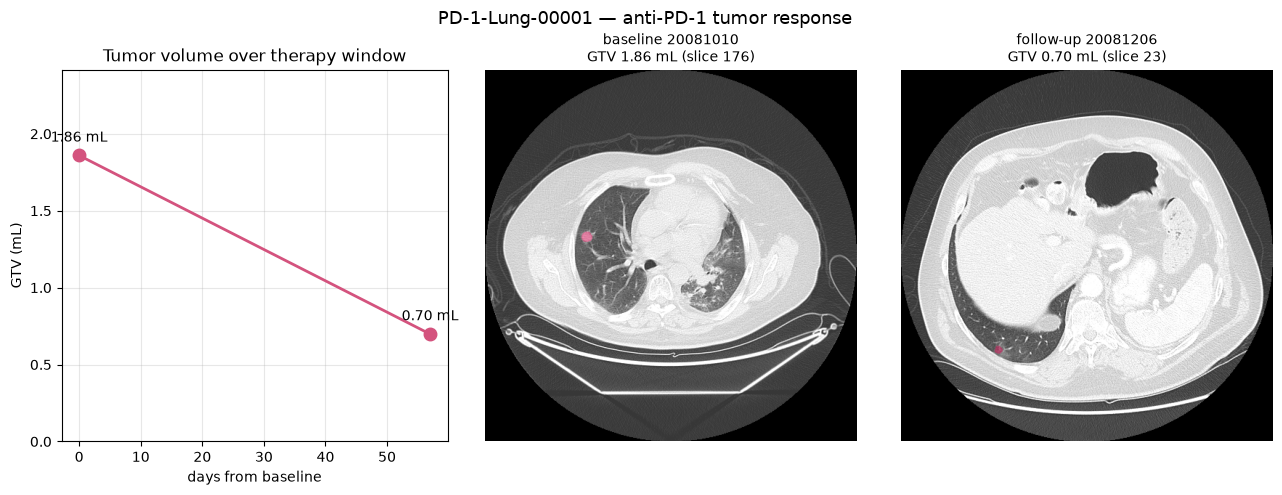

In [8]:
fig = plt.figure(figsize=(13, 5))

# (a) GTV over time
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(meta["days_from_baseline"], meta["GTV_mL"], "o-", color="#D4537E", lw=2, ms=9)
for _, r in meta.iterrows():
    ax1.annotate(f"{r['GTV_mL']:.2f} mL", (r["days_from_baseline"], r["GTV_mL"]),
                 textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)
ax1.set_xlabel("days from baseline"); ax1.set_ylabel("GTV (mL)")
ax1.set_title("Tumor volume over therapy window"); ax1.grid(alpha=0.3)
ax1.set_ylim(0, max(meta["GTV_mL"]) * 1.3)

# (b,c) tumor overlay at first and last timepoint
def best_slice(mask):
    return int(np.argmax(mask.reshape(mask.shape[0], -1).sum(axis=1)))

for j, date in enumerate([meta.iloc[0]["StudyDate"], meta.iloc[-1]["StudyDate"]]):
    ax = fig.add_subplot(1, 3, 2 + j)
    cimg = ct_images[date]; ctarr = sitk.GetArrayFromImage(cimg)
    mask = gtv_masks[date]; z = best_slice(mask)
    lo, hi = -600 - 750, -600 + 750                      # lung window
    base = np.clip((ctarr[z].astype(float) - lo) / (hi - lo), 0, 1)
    rgb = np.stack([base]*3, axis=-1)
    rgb[..., 0][mask[z]] = 0.55 * rgb[..., 0][mask[z]] + 0.45 * 0.85
    rgb[..., 1][mask[z]] = 0.55 * rgb[..., 1][mask[z]]
    rgb[..., 2][mask[z]] = 0.55 * rgb[..., 2][mask[z]] + 0.45 * 0.30
    vol = meta.loc[meta.StudyDate == date, "GTV_mL"].iloc[0]
    ax.imshow(rgb); ax.axis("off")
    ax.set_title(f"{'baseline' if j==0 else 'follow-up'} {date}\nGTV {vol:.2f} mL (slice {z})", fontsize=10)

fig.suptitle(f"{PATIENT} — anti-PD-1 tumor response", fontsize=13)
fig.tight_layout()
fig.savefig("gtv_growth_tracking.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Interpretation and citations

**Result.** Over the ~2-month window, this patient's tumor volume falls sharply — a volumetric
**treatment response** to anti-PD-1 immunotherapy (negative VDT). This is the longitudinal quantity
NSCLC-Radiomics could not provide for a single-timepoint patient. The same CSV/record structure used in
the `organ_segmentation.ipynb` notebook is written here (`timepoint_records.csv`), so the two workflows
are interoperable.

**Extending this:** drop more `anti_pd_1_lung` patients into the `PATIENT` config to build a cohort of
growth/response trajectories; or substitute a screening collection (`nlst`) for indolent-vs-aggressive
growth kinetics.

**Citations**
- *Imaging collection (anti-PD-1 immunotherapy lung):* the `anti_pd_1_lung` collection in The Cancer
  Imaging Archive (TCIA). Check `client.citations_from_selection(collection_id="anti_pd_1_lung")` for the
  exact data-citation DOI at your data version.
- *AI tumor/nodule segmentations:* BAMF Health / IDC AIMI annotations — Murugesan, G. K., et al. (2023).
  *AI-generated annotations for several IDC collections (BAMF)* [Dataset]. Zenodo.
  https://doi.org/10.5281/zenodo.8345959
- *The Cancer Imaging Archive:* Clark, K., et al. (2013). *Journal of Digital Imaging*, 26(6), 1045–1057.
  https://doi.org/10.1007/s10278-013-9622-7
- *Imaging Data Commons:* Fedorov, A., et al. (2023). *RadioGraphics*, 43(12), e230180.
  https://doi.org/10.1148/rg.230180
- *Volume doubling time as a lung-cancer growth/prognosis metric:* Jiang, B., et al. (2024). Lung cancer
  volume doubling time by CT: a systematic review and meta-analysis. *European Journal of Cancer*.
  https://doi.org/10.1016/j.ejca.2024.114120